In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari
!ls -la

/content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari
total 41
drwx------ 2 root root  4096 Sep 25 15:17 code
drwx------ 2 root root  4096 Sep 25 15:04 .git
-rw------- 1 root root 13586 Oct 31 06:01 github_terminal.ipynb
-rw------- 1 root root    33 Sep 26 19:25 .gitignore
drwx------ 2 root root  4096 Sep 25 15:17 models
drwx------ 2 root root  4096 Oct 31 02:25 OLD
-rw------- 1 root root  2348 Sep 29 02:21 README.md
drwx------ 2 root root  4096 Sep 25 15:17 results
drwx------ 2 root root  4096 Oct 18 05:10 videos


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

print("All imports working")

All imports working


In [ ]:
def show_histogram(arr, label):
  # Histogram
  plt.hist(arr, alpha=0.7, label=label, bins=20)
  plt.xlabel('Episode Reward')
  plt.ylabel('Frequency')
  plt.legend()
  plt.title(f'{label} Agent Reward Distribution')
  plt.show()

In [ ]:
def show_boxplot(arr, label):
  # Box Plot
  plt.figure(figsize=(8, 5))
  plt.boxplot([arr], labels=[label])
  plt.ylabel('Episode Reward')
  plt.title(f'{label} Agent Reward Distribution')
  plt.show()

In [ ]:
def plot_three_histograms_overlay(arr1, arr2, arr3, label1, label2, label3):
    plt.figure(figsize=(10, 6))

    plt.hist(arr1, alpha=0.5, label=label1, bins=20)
    plt.hist(arr2, alpha=0.5, label=label2, bins=20)
    plt.hist(arr3, alpha=0.5, label=label3, bins=20)

    plt.xlabel('Episode Reward')
    plt.ylabel('Frequency')
    plt.title(f'Reward Distribution: {label1} vs {label2} vs {label3}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_two_histograms_overlay(arr1, arr2, label1, label2, color1='C0', color2='C1'):
    plt.figure(figsize=(10, 6))

    plt.hist(arr1, alpha=0.5, label=label1, bins=20, color=color1)
    plt.hist(arr2, alpha=0.5, label=label2, bins=20, color=color2)

    plt.xlabel('Episode Reward')
    plt.ylabel('Frequency')
    plt.title(f'Reward Distribution: {label1} vs {label2}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_three_histograms(arr1, arr2, arr3, label1, label2, label3):
    plt.figure(figsize=(15, 5))

    # Get global min/max so all 3 have the same scaled x-axis
    all_data = np.concatenate([arr1, arr2, arr3])
    x_min, x_max = np.min(all_data), np.max(all_data)

    # Plot 1
    plt.subplot(1, 3, 1)
    plt.hist(arr1, alpha=0.7, bins=20, range=(x_min, x_max))
    plt.xlabel('Episode Reward')
    plt.ylabel('Frequency')
    plt.title(label1)
    plt.grid(True, alpha=0.3)

    # Plot 2
    plt.subplot(1, 3, 2)
    plt.hist(arr2, alpha=0.7, bins=20, range=(x_min, x_max), color='C1')
    plt.xlabel('Episode Reward')
    plt.ylabel('Frequency')
    plt.title(label2)
    plt.grid(True, alpha=0.3)

    # Plot 3
    plt.subplot(1, 3, 3)
    plt.hist(arr3, alpha=0.7, bins=20, range=(x_min, x_max), color='C2')
    plt.xlabel('Episode Reward')
    plt.ylabel('Frequency')
    plt.title(label3)
    plt.grid(True, alpha=0.3)

    plt.suptitle('Reward Distributions Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
folder = "/content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari/results"

In [ ]:
def load_npy_file(file_name):
  file_path = f"{folder}/{file_name}"
  arr = np.load(file_path)
  return arr

In [ ]:
# List all files
files = os.listdir(folder)
print(f"Files in {folder}:")

reward_file_names = []
for file in files:
  if "all_" in file and "_rewards" in file:
    print(file)
    reward_file_names.append(file)

Files in /content/drive/MyDrive/MECE689_Bowling/MECE689_RL_Bowling_Atari/results:
all_random_rewards.npy
all_dqn_baseline_rewards.npy
all_QR_dqn_rewards.npy
all_PPO_rewards.npy
all_A2C_rewards.npy
all_A2C_Ablation_Study_1_rewards.npy
all_A2C_Ablation_Study_2_rewards.npy
all_A2C_Ablation_Study_3_rewards.npy
all_PPO_HP_Tuning_2_rewards.npy
all_PPO_HP_Tuning_1_rewards.npy
all_PPO_HP_Tuning_3_rewards.npy
all_PPO_HP_Tuning_5_rewards.npy
all_PPO_HP_Tuning_4_rewards.npy
all_PPO_HP_Tuning_7_rewards.npy
all_PPO_HP_Tuning_6_rewards.npy
all_A2C_Ablation_Study_4_rewards.npy


In [ ]:
labels = []

In [ ]:
for file_name in reward_file_names:
  label = "_".join(file_name.split("_")[1:5])
  if "_rewards.npy" in label:
    label = label.split("_rewards")[0]
  if "dqn" in file_name and "QR_dqn" not in file_name:
    label = "DQN"
  if "random" in file_name:
    label = "Random"

  print(label)
  labels.append(label)

Random
DQN
QR_dqn
PPO
A2C
A2C_Ablation_Study_1
A2C_Ablation_Study_2
A2C_Ablation_Study_3
PPO_HP_Tuning_2
PPO_HP_Tuning_1
PPO_HP_Tuning_3
PPO_HP_Tuning_5
PPO_HP_Tuning_4
PPO_HP_Tuning_7
PPO_HP_Tuning_6
A2C_Ablation_Study_4


In [ ]:
n = len(labels)

In [ ]:
# Load all data first
results_dict_unsorted = {}

for i in range(n):
    file_name = reward_file_names[i]
    label = labels[i]
    arr = load_npy_file(file_name)
    # Save to dict
    results_dict_unsorted[label] = arr

# Sort dictionary by keys, alphabetically
results_dict = dict(sorted(results_dict_unsorted.items()))

In [ ]:
results_dict

{'A2C': array([ 81., 103., 110., ..., 110., 128., 110.], dtype=float32),
 'A2C_Ablation_Study_1': array([95., 55., 76., ..., 76., 53., 76.], dtype=float32),
 'A2C_Ablation_Study_2': array([100.,  90.,  95., ..., 129.,  73., 129.], dtype=float32),
 'A2C_Ablation_Study_3': array([120.,  95., 126., ..., 126.,  76., 126.], dtype=float32),
 'A2C_Ablation_Study_4': array([90., 86., 70., ..., 70., 86., 70.], dtype=float32),
 'DQN': array([ 74., 121.,  83., ...,  70.,  78.,  78.], dtype=float32),
 'PPO': array([188., 183., 203., ..., 187., 108., 176.], dtype=float32),
 'PPO_HP_Tuning_1': array([  0.,  38.,  68., ...,  49., 110.,  36.], dtype=float32),
 'PPO_HP_Tuning_2': array([103., 172., 130., ..., 168., 120., 132.], dtype=float32),
 'PPO_HP_Tuning_3': array([ 82.,  94.,  73., ..., 127.,  95., 107.], dtype=float32),
 'PPO_HP_Tuning_4': array([ 46., 190., 178., ..., 179.,  25., 180.], dtype=float32),
 'PPO_HP_Tuning_5': array([138., 159., 138., ..., 169., 132., 153.], dtype=float32),
 'PPO_HP

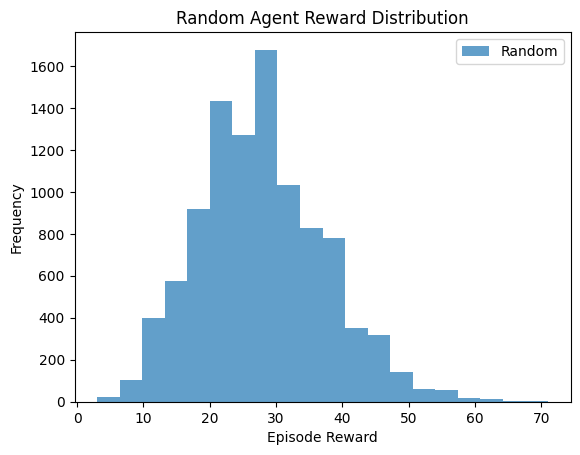

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


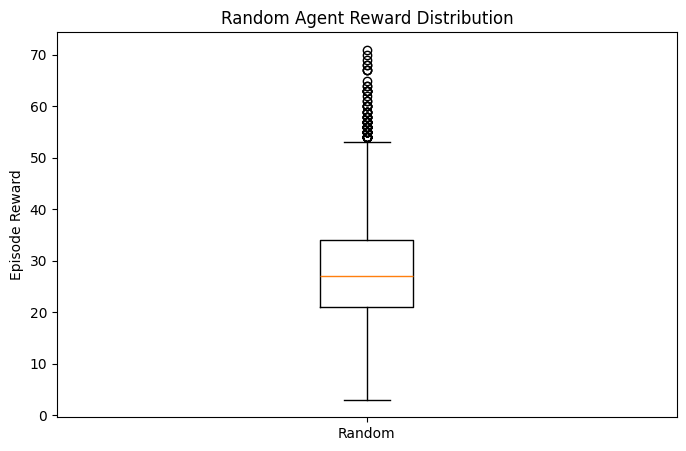

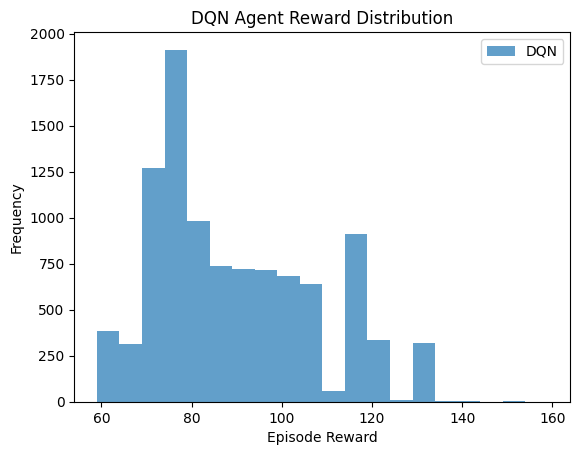

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


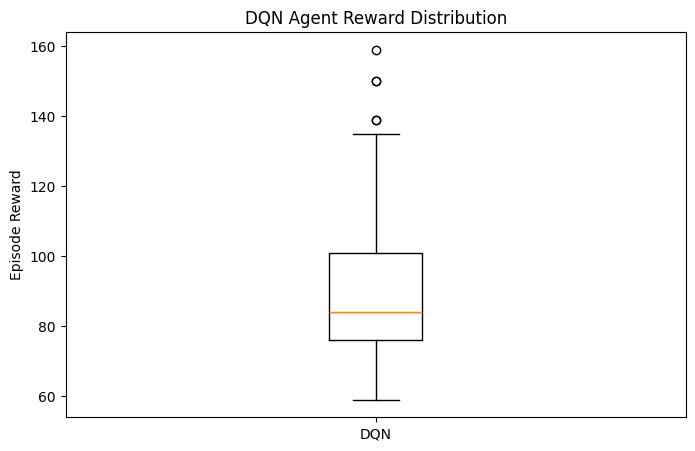

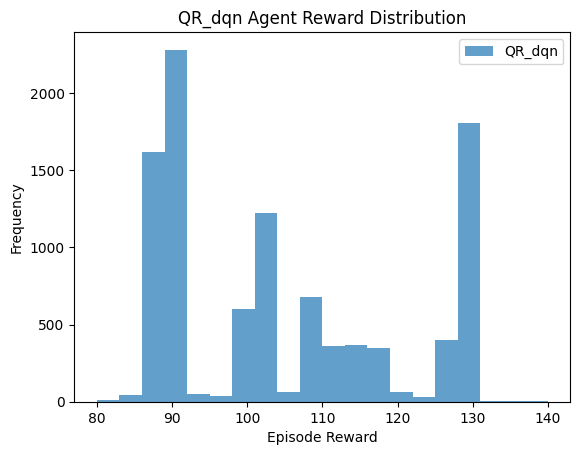

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


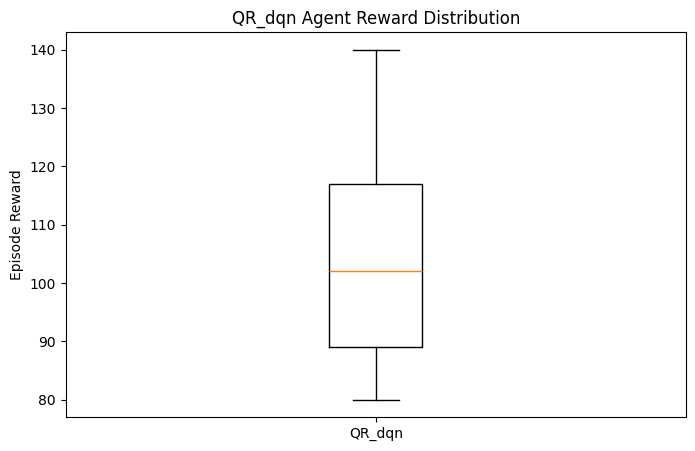

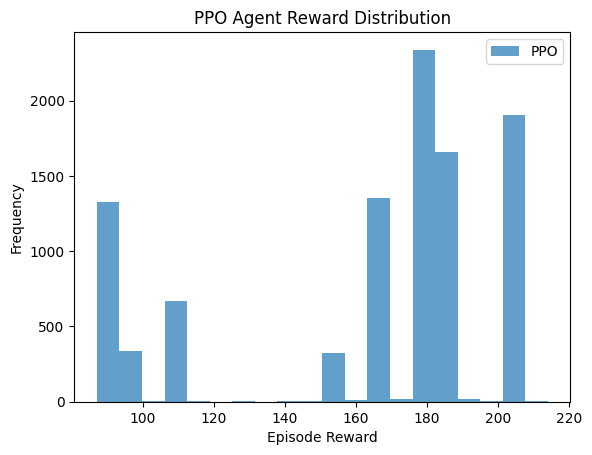

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


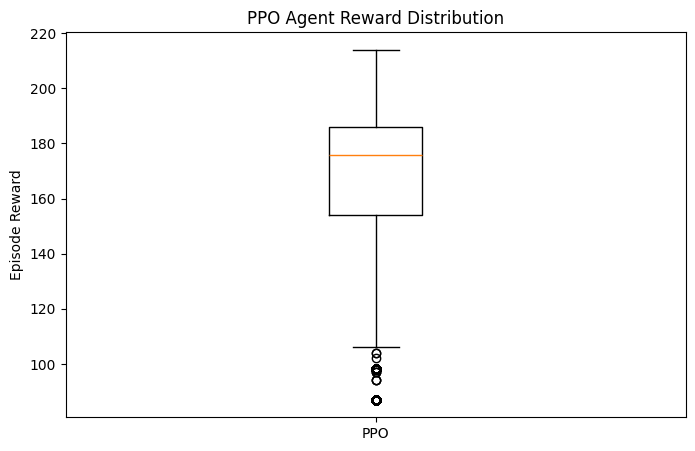

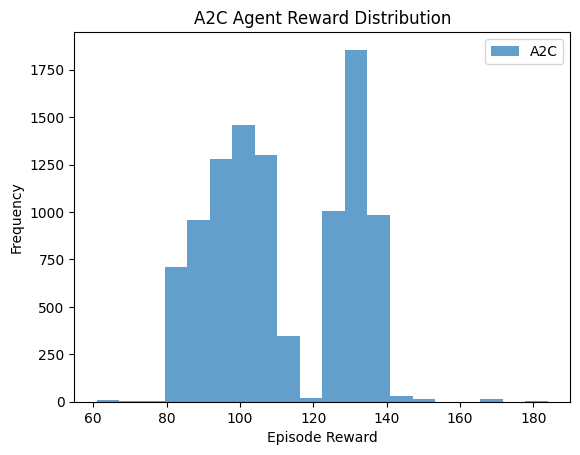

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


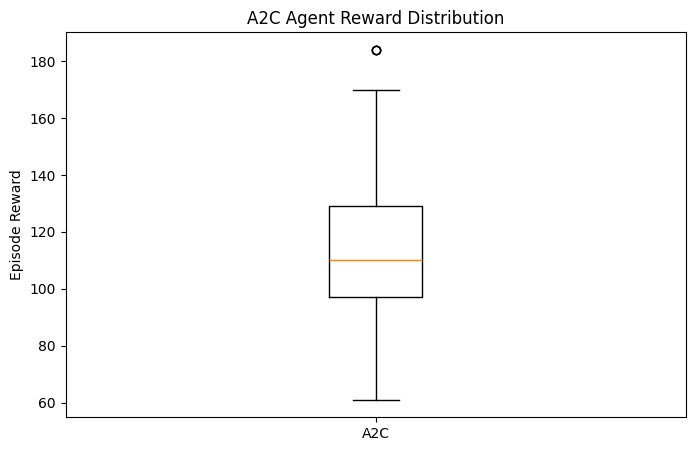

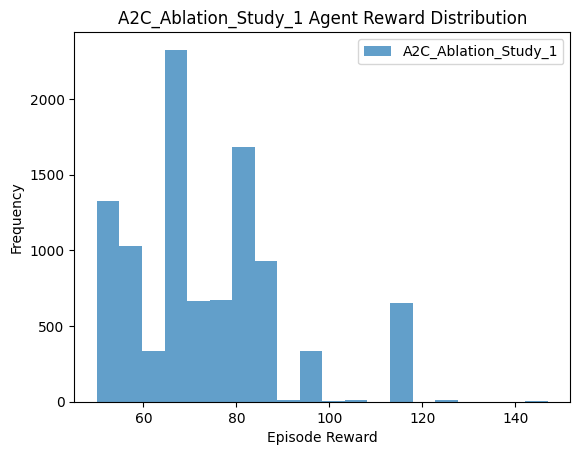

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


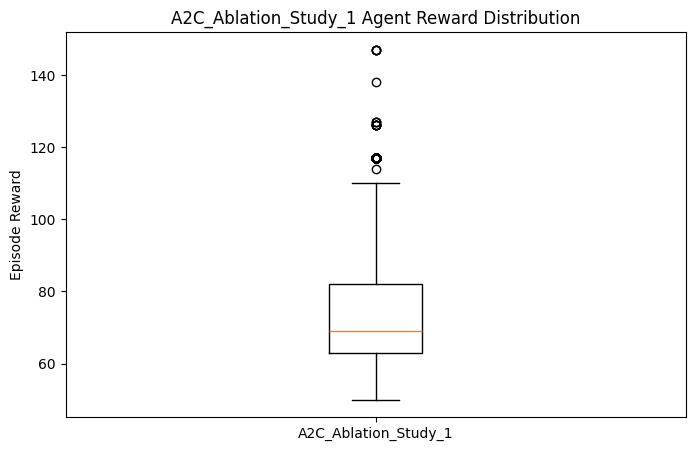

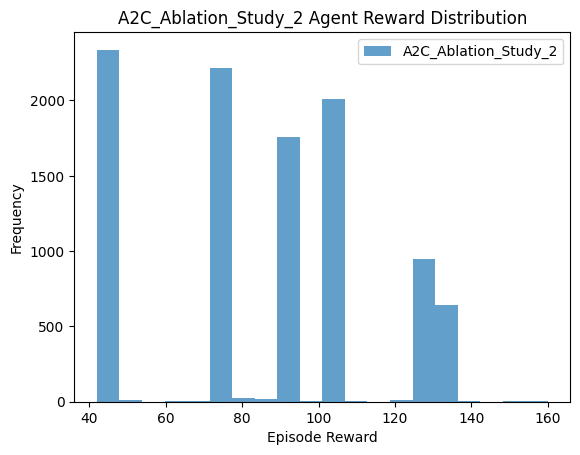

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


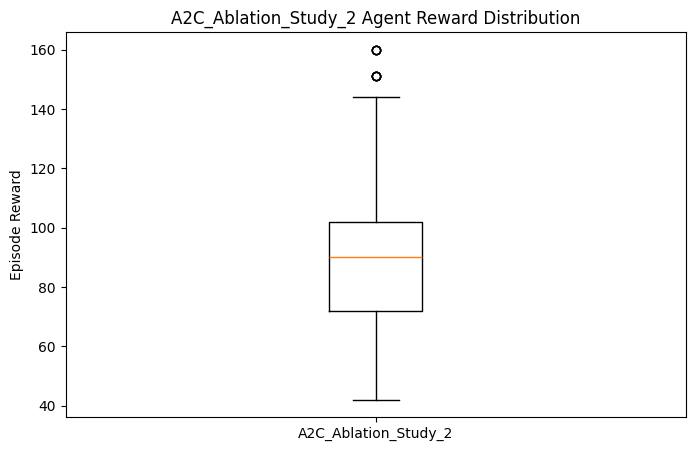

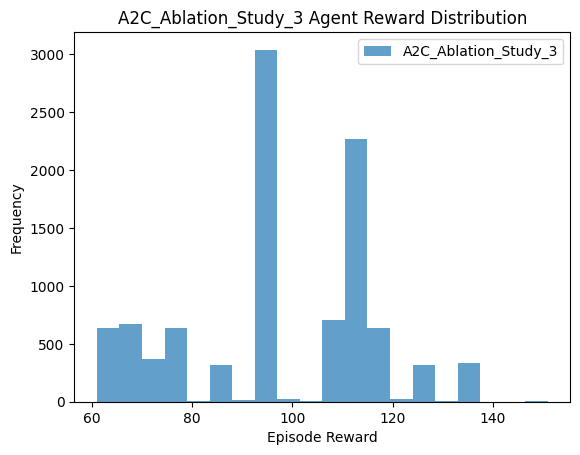

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


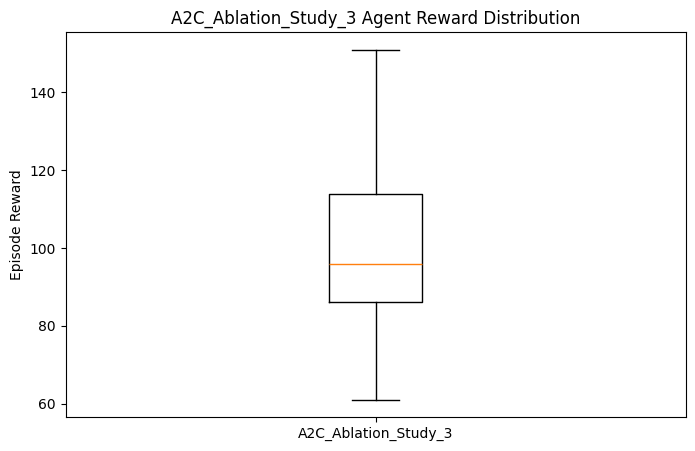

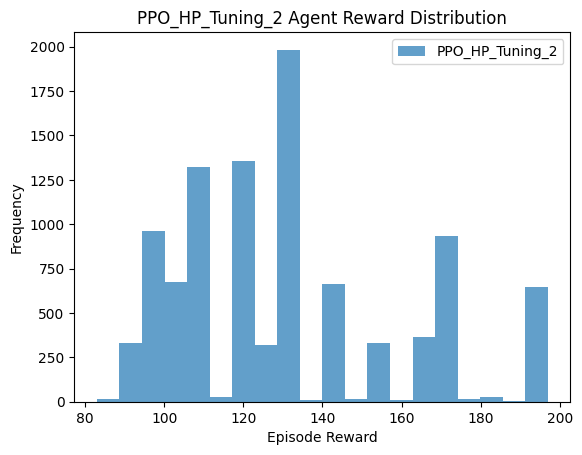

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


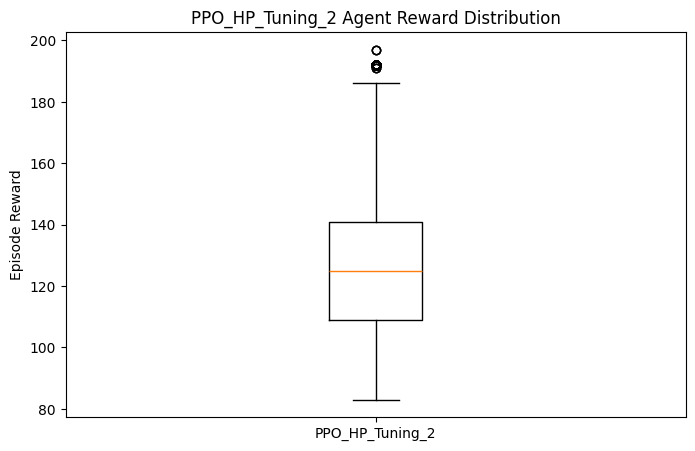

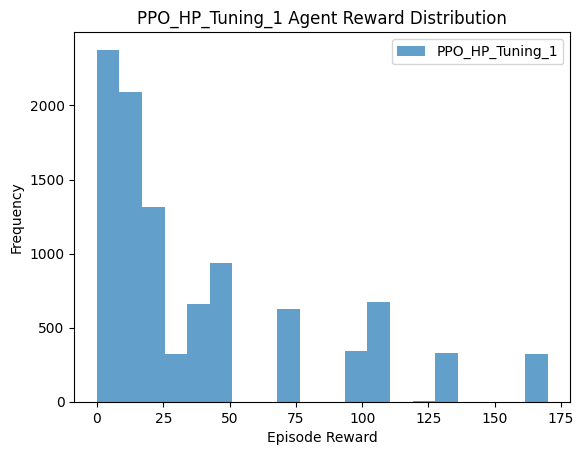

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


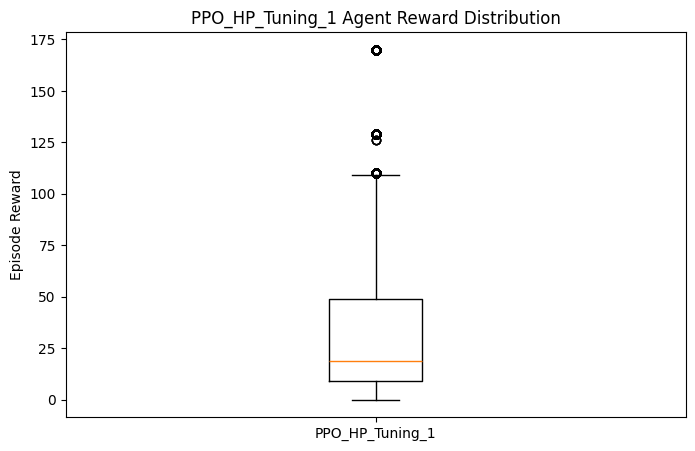

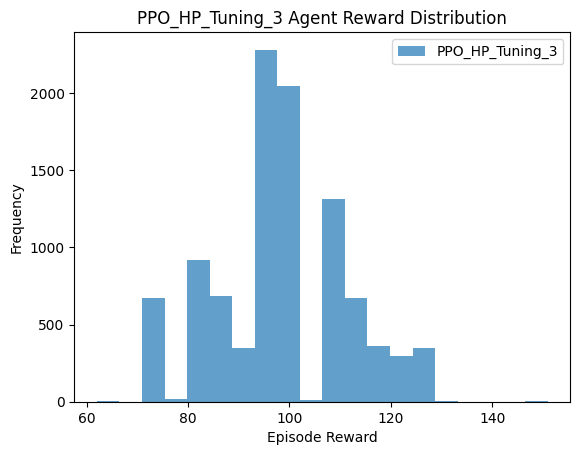

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


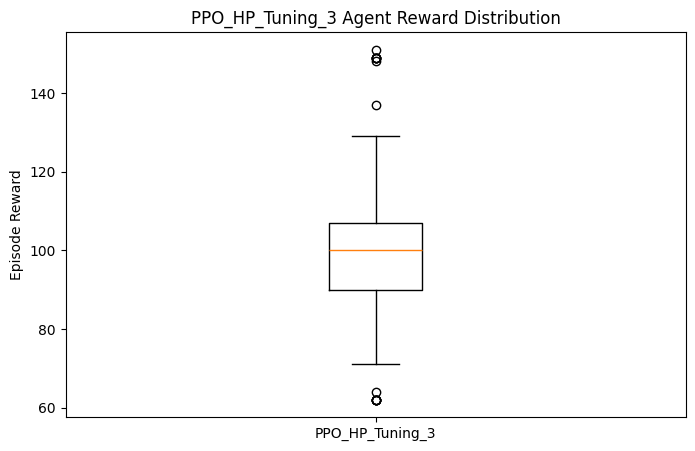

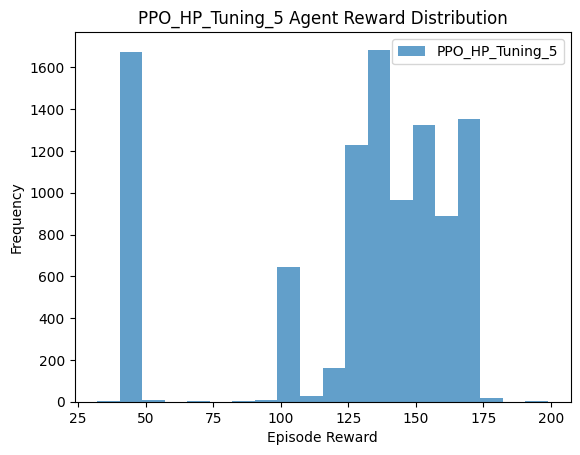

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


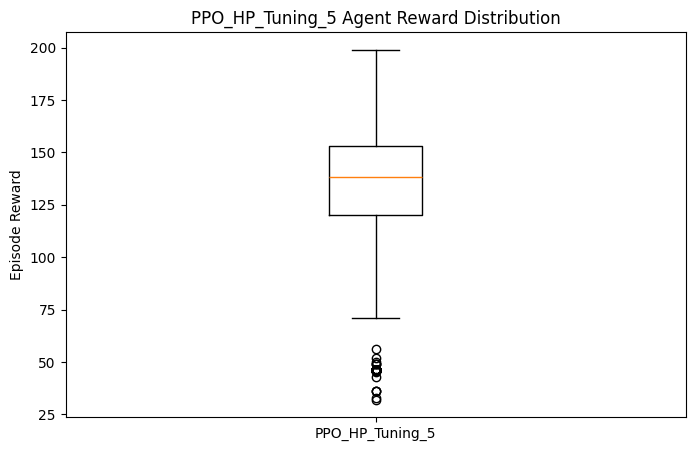

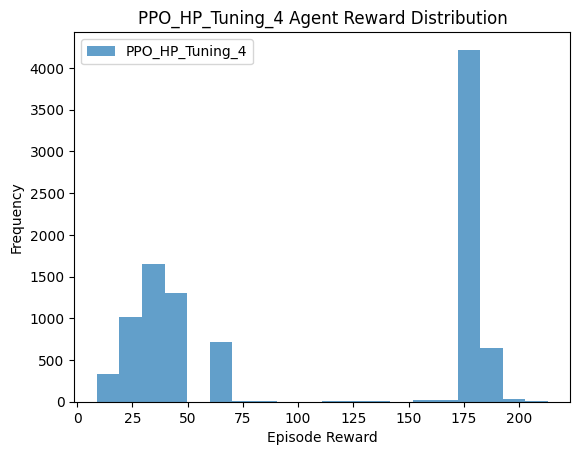

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


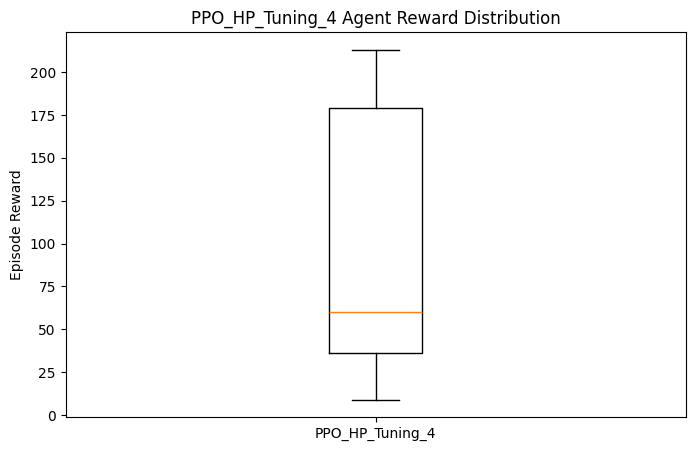

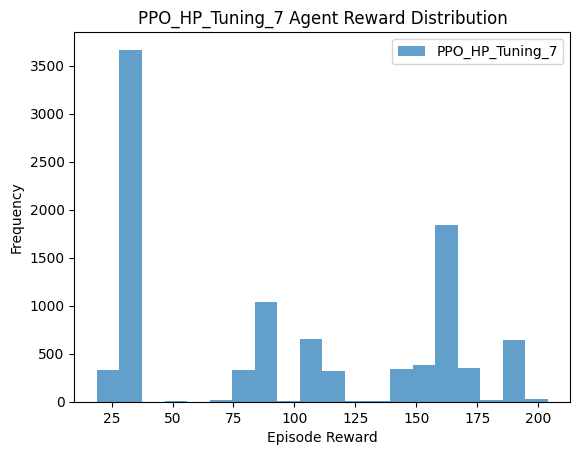

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


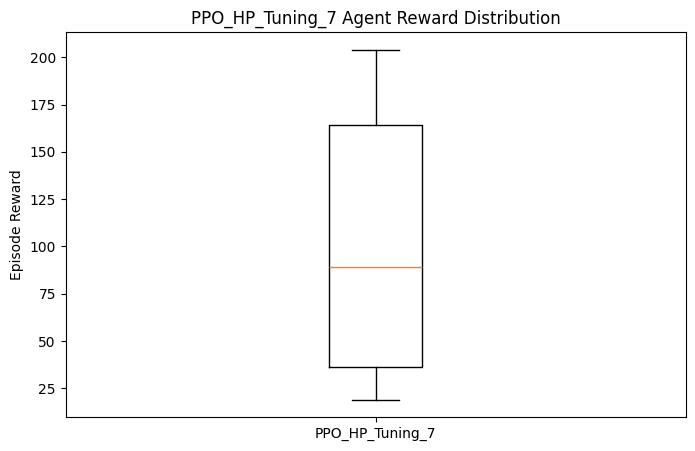

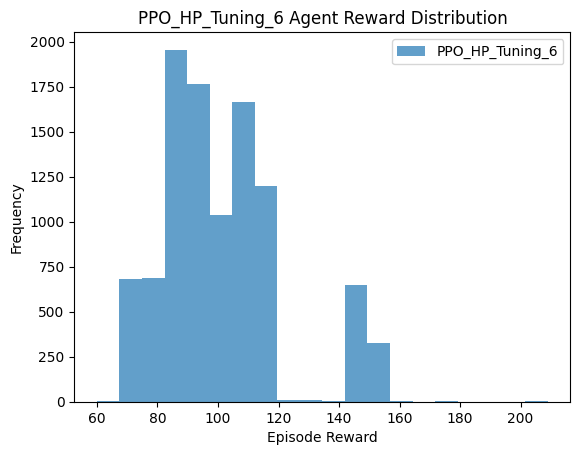

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


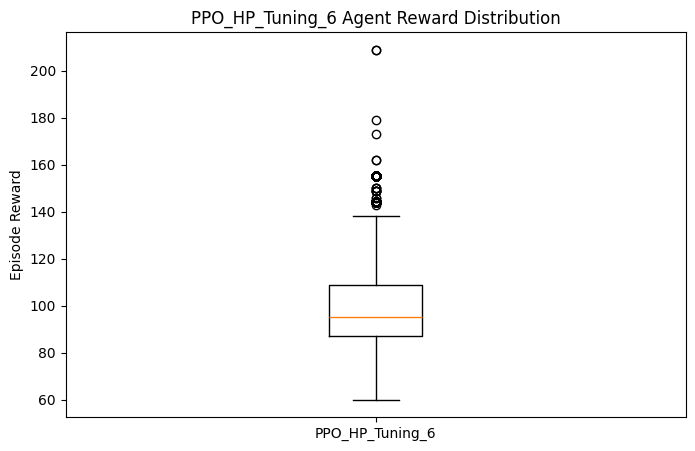

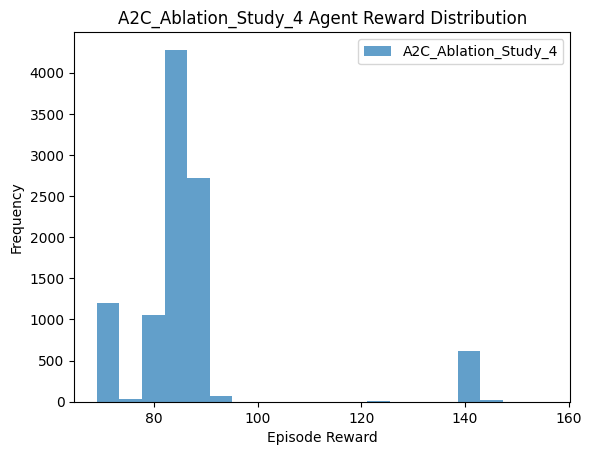

/tmp/ipython-input-2988661204.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([arr], labels=[label])


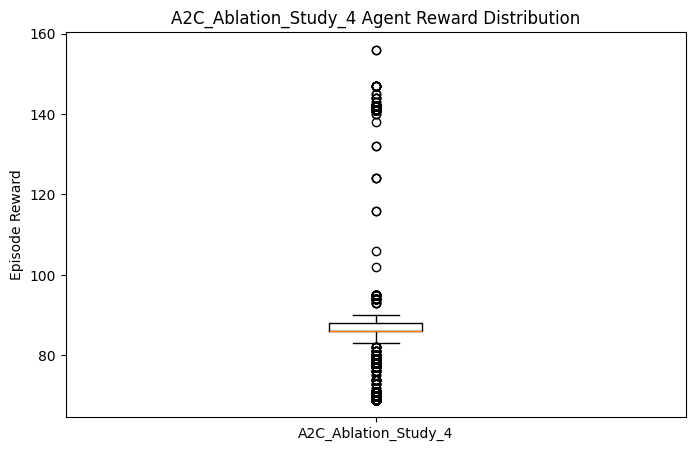

In [ ]:
# for i in range(n):
#   file_name = reward_file_names[i]
#   label = labels[i]
#   arr = load_npy_file(file_name)

#   show_histogram(arr, label)
#   show_boxplot(arr, label)

Plot Histograms

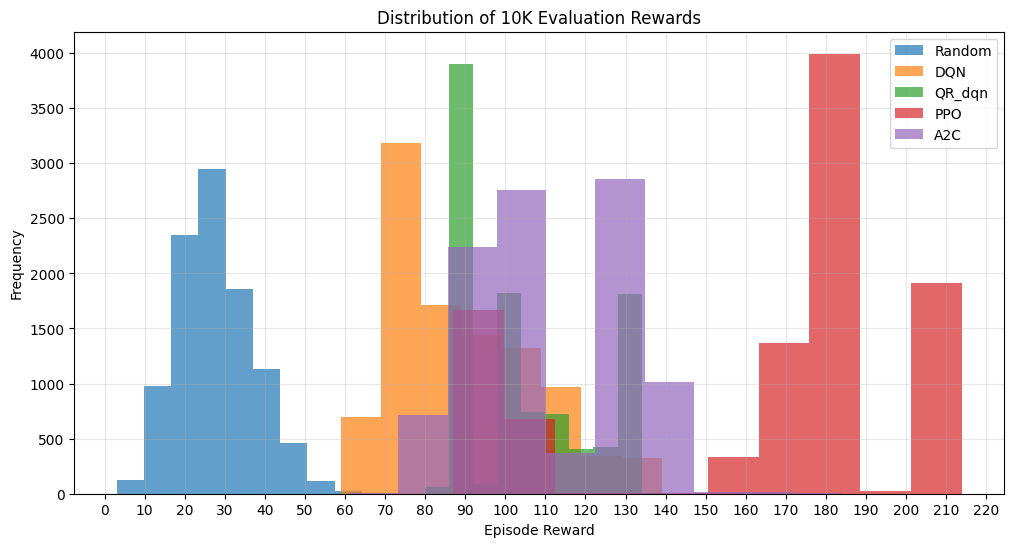

In [ ]:
# Histogram overlay of Random, DQN, QRDQN, A2C, PPO (The main 4 algorithms)
plt.figure(figsize=(12, 6))
for i in range(5):
  file_name = reward_file_names[i]
  label = labels[i]
  arr = load_npy_file(file_name)
  plt.hist(arr, alpha=0.7, label=label, bins=10)

plt.xlabel('Episode Reward')
plt.ylabel('Frequency')
plt.title('Distribution of 10K Evaluation Rewards')
plt.locator_params(axis='x', nbins=30)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

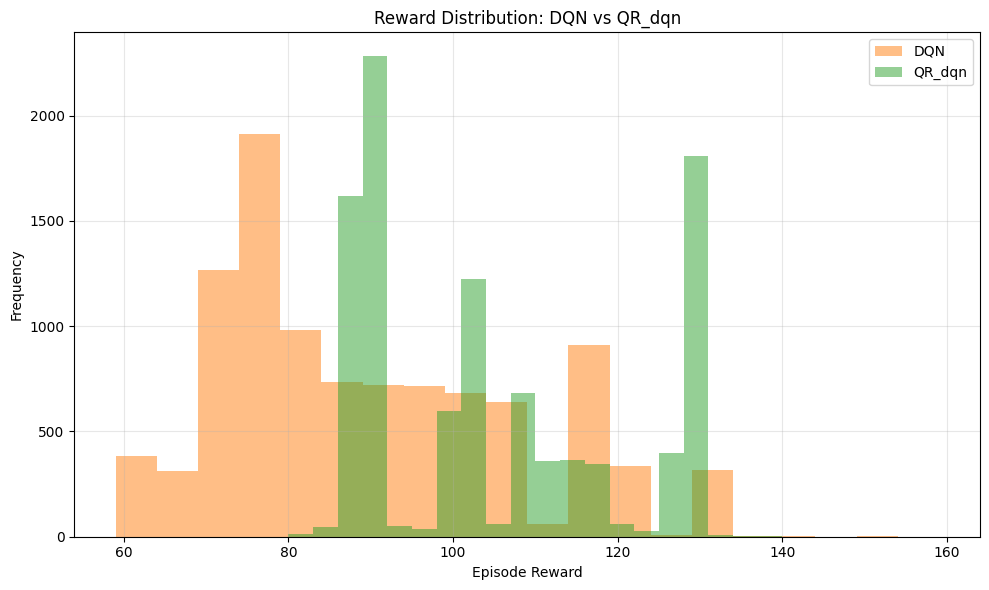

In [ ]:
# Histogram Overlay of DQN vs. QRDQN
label1='DQN'
label2='QR_dqn'
arr1 = results_dict[label1]
arr2 = results_dict[label2]
plot_two_histograms_overlay(arr1, arr2, label1, label2, 'C1', 'C2')

/tmp/ipython-input-2519599208.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_arrays, labels=all_labels, showmeans=True)


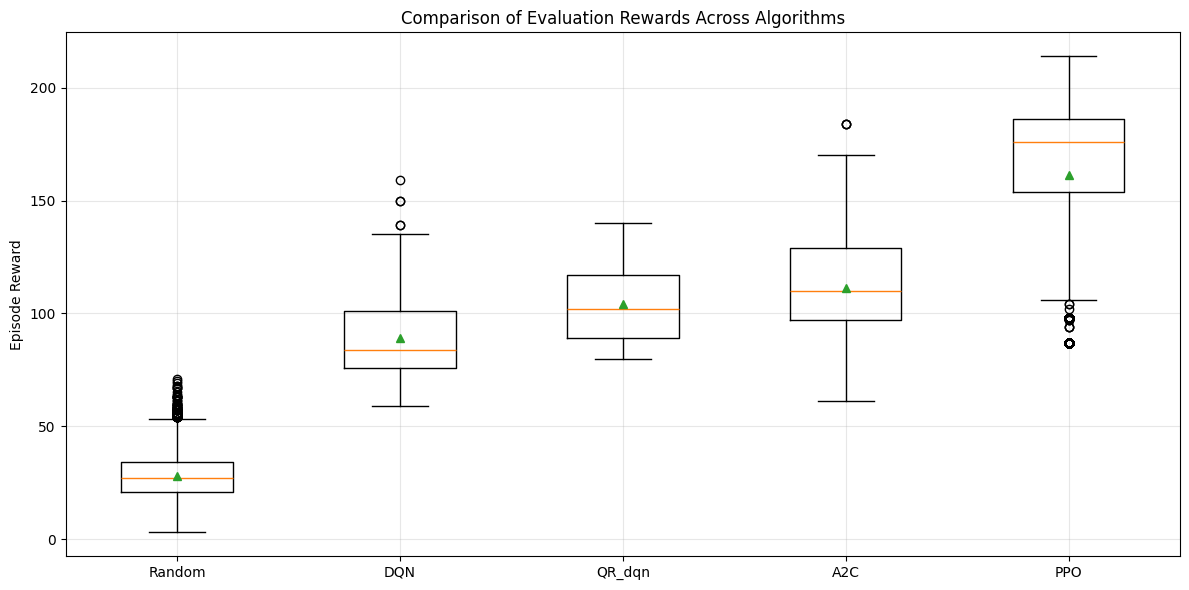

In [ ]:
# Box plot Comparison btwn Random, DQN, QRDQN, A2C, and PPO
all_arrays = []
all_labels = []

indexes = [0,1,2,4,3]
for i in indexes:
  # 0, 1, 2, 4, 3
  file_name = reward_file_names[i]
  label = labels[i]
  arr = load_npy_file(file_name)
  all_arrays.append(arr)
  all_labels.append(label)

# Box plot with all 5 side by side
plt.figure(figsize=(12, 6))
plt.boxplot(all_arrays, labels=all_labels, showmeans=True)
plt.ylabel('Episode Reward')
plt.title('Comparison of Evaluation Rewards Across Algorithms')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

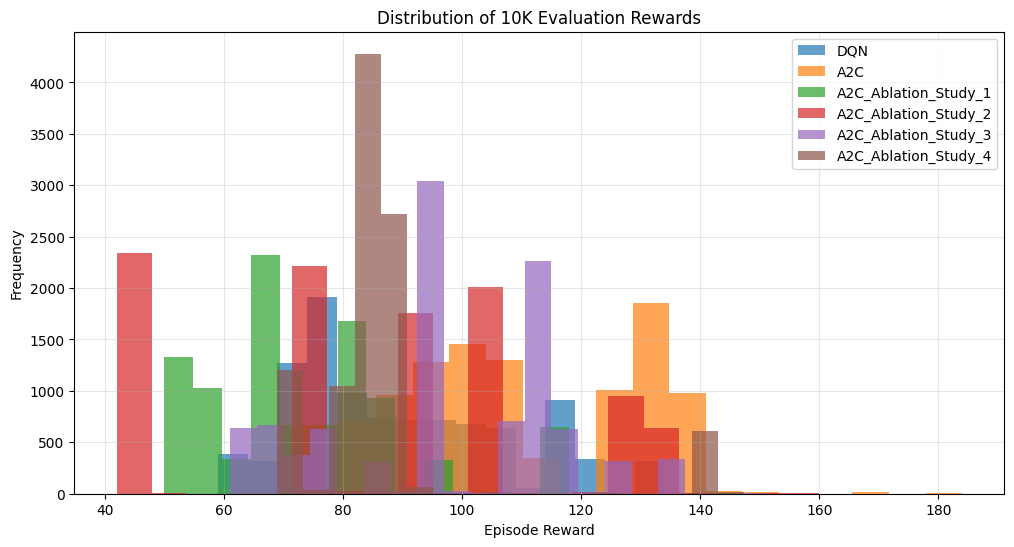

In [ ]:
# Histogram Overlay of DQN, A2C, and 4 A2C Ablation Studies
plt.figure(figsize=(12, 6))
for i in range(n):
  file_name = reward_file_names[i]
  label = labels[i]
  if "DQN" == label or "A2C" in label:
    arr = load_npy_file(file_name)
    plt.hist(arr, alpha=0.7, label=label, bins=20)

plt.xlabel('Episode Reward')
plt.ylabel('Frequency')
plt.title('Distribution of 10K Evaluation Rewards')
plt.locator_params(axis='x', nbins=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

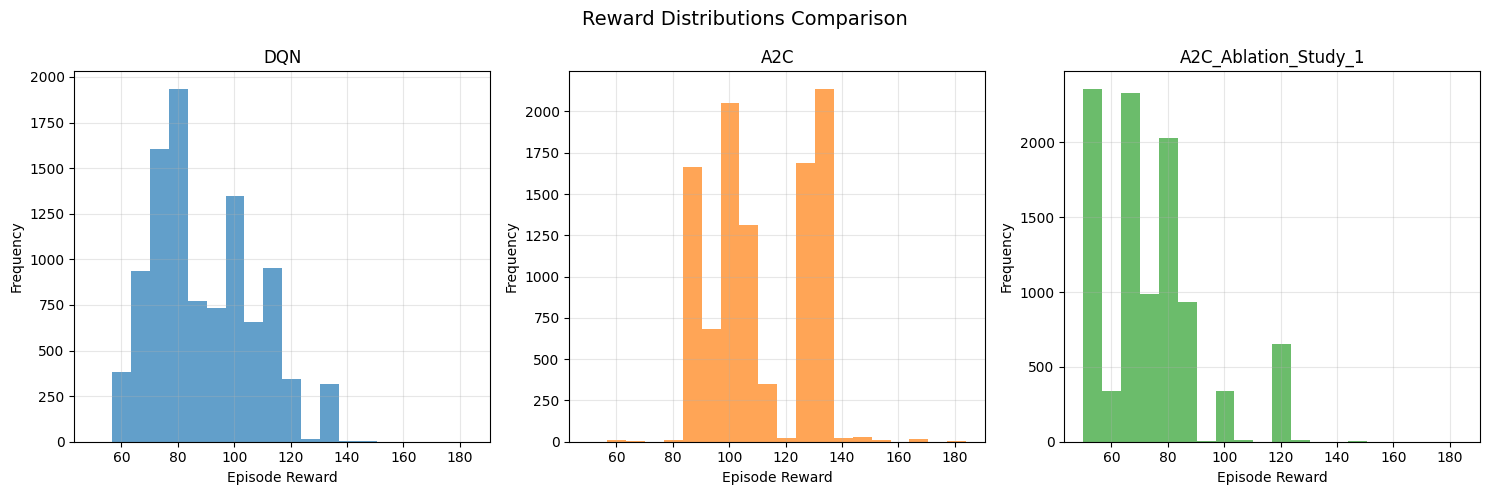

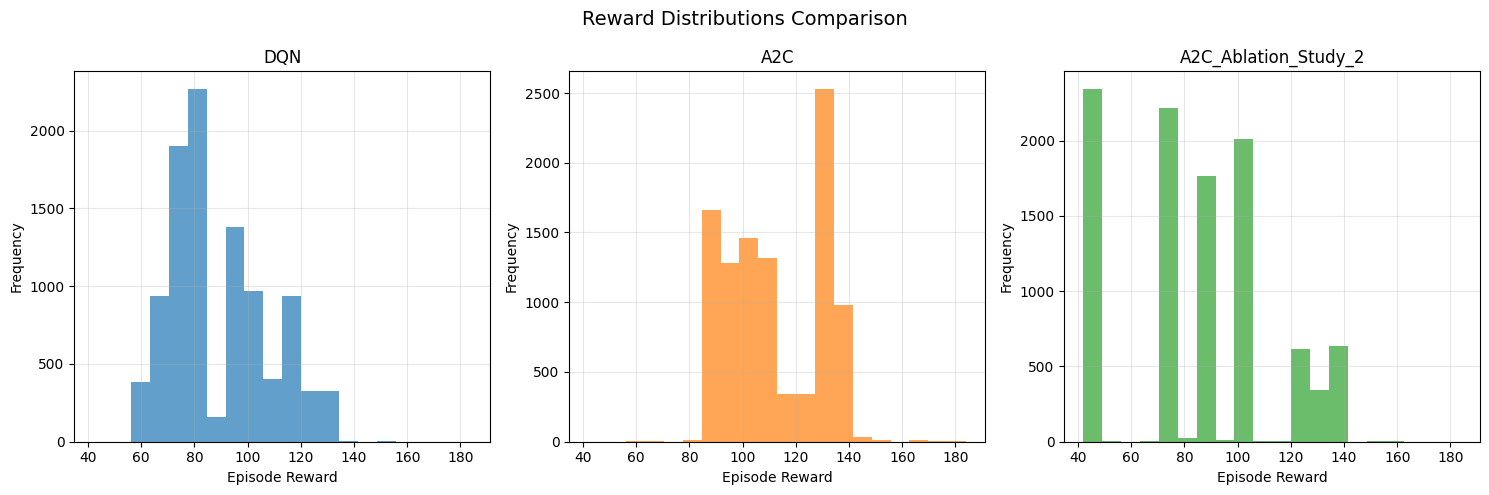

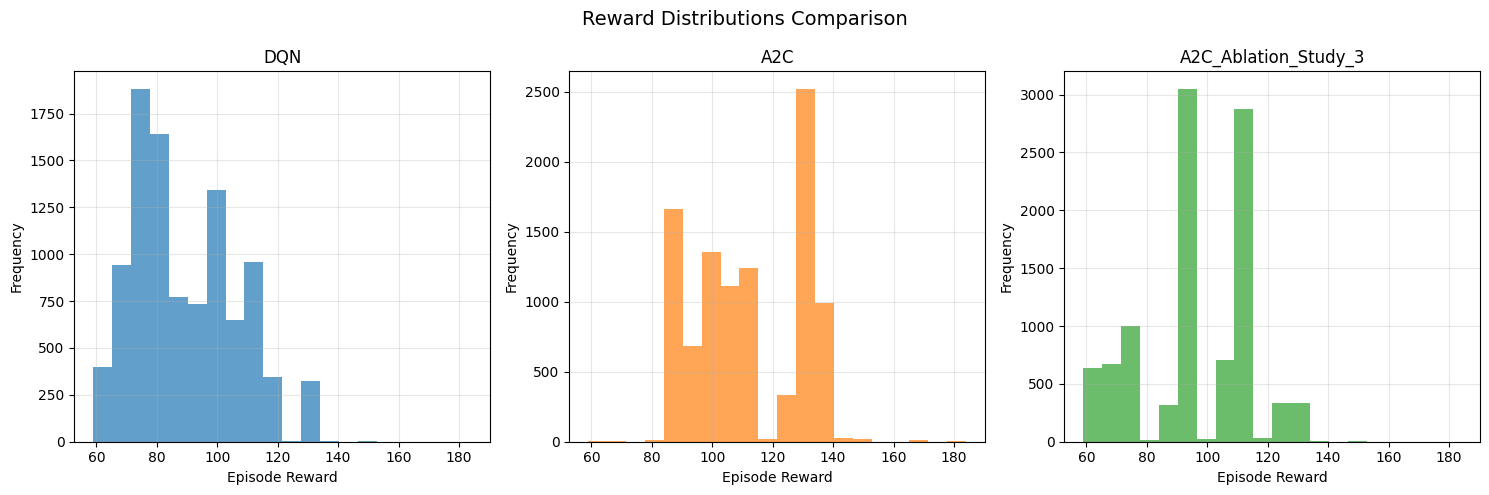

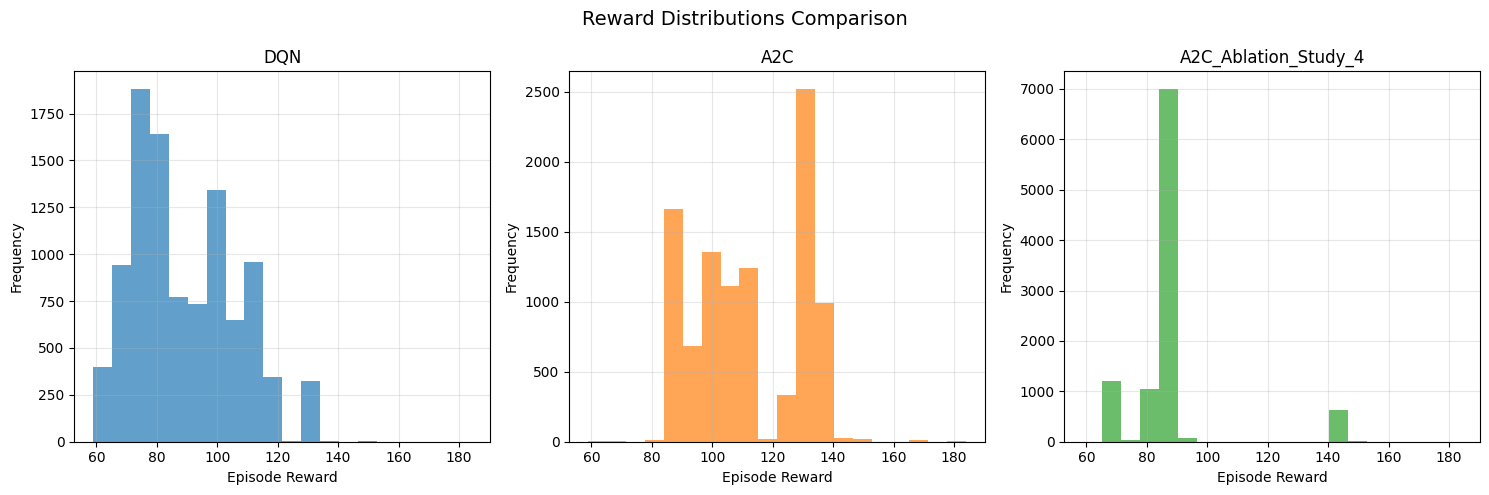

In [ ]:
# Side by side individual Histograms of DQN vs. A2C vs. A2C Ablation Studies
keys = ["DQN", "A2C"]

for i in range(n):
  file_name = reward_file_names[i]
  label = labels[i]
  if "A2C" in label and label != "A2C":
    arr = load_npy_file(file_name)

    plot_three_histograms(results_dict[keys[0]], results_dict[keys[1]], arr, keys[0], keys[1], label)

/tmp/ipython-input-1448977122.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_arrays, labels=all_labels, showmeans=True)


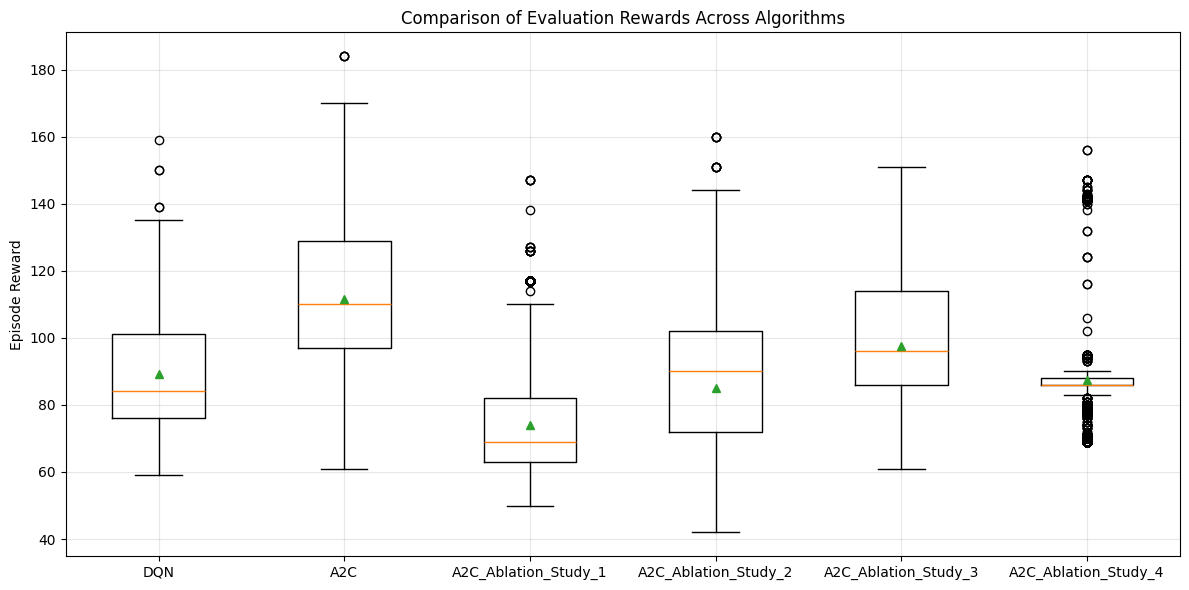

In [ ]:
# Box Plots of DQN vs. A2C vs. all A2C Ablation Studies
all_arrays = []
all_labels = []

for i in range(n):
    file_name = reward_file_names[i]
    label = labels[i]
    if "DQN" == label or "A2C" in label:
      arr = load_npy_file(file_name)
      all_arrays.append(arr)
      all_labels.append(label)

# Box plot with all side by side
plt.figure(figsize=(12, 6))
plt.boxplot(all_arrays, labels=all_labels, showmeans=True)
plt.ylabel('Episode Reward')
plt.title('Comparison of Evaluation Rewards Across Algorithms')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

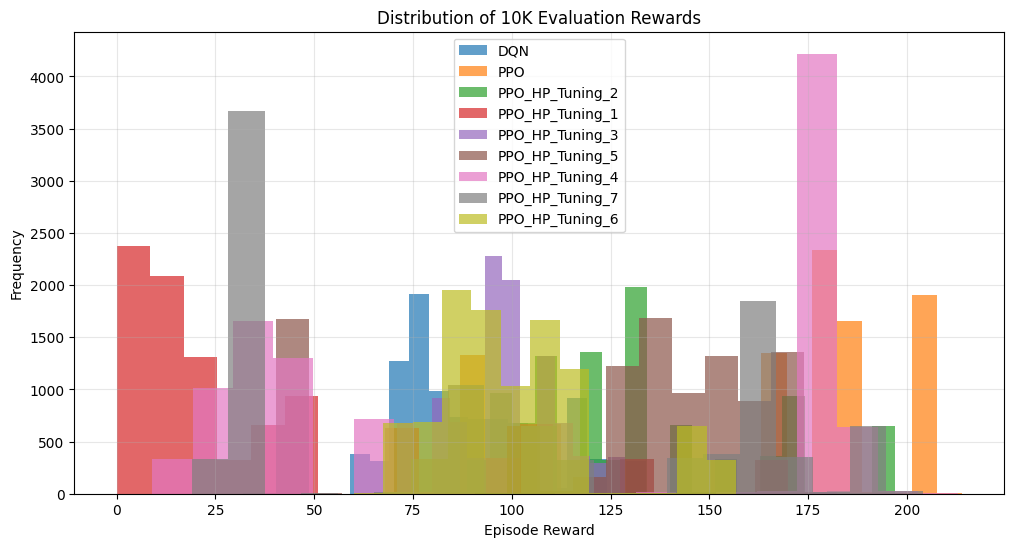

In [ ]:
# Overlay of Histograms of DQN, PPO, and all 7 PPO HP Tuning
plt.figure(figsize=(12, 6))
for i in range(n):
  file_name = reward_file_names[i]
  label = labels[i]
  if "DQN" == label or "PPO" in label:
    arr = load_npy_file(file_name)
    plt.hist(arr, alpha=0.7, label=label, bins=20)

plt.xlabel('Episode Reward')
plt.ylabel('Frequency')
plt.title('Distribution of 10K Evaluation Rewards')
plt.locator_params(axis='x', nbins=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

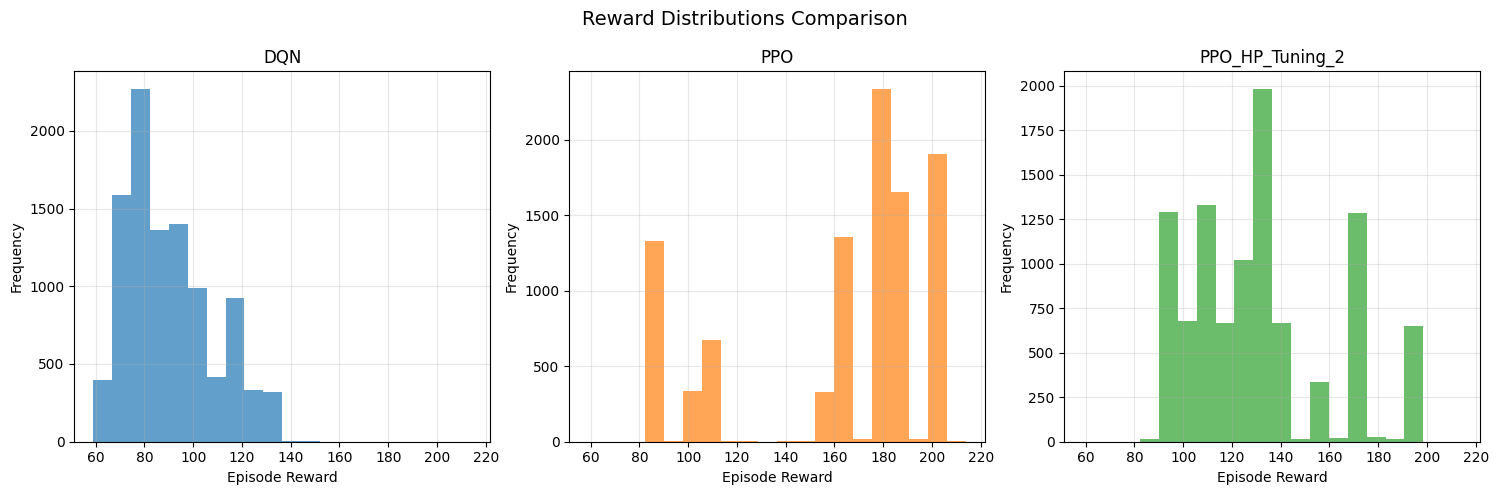

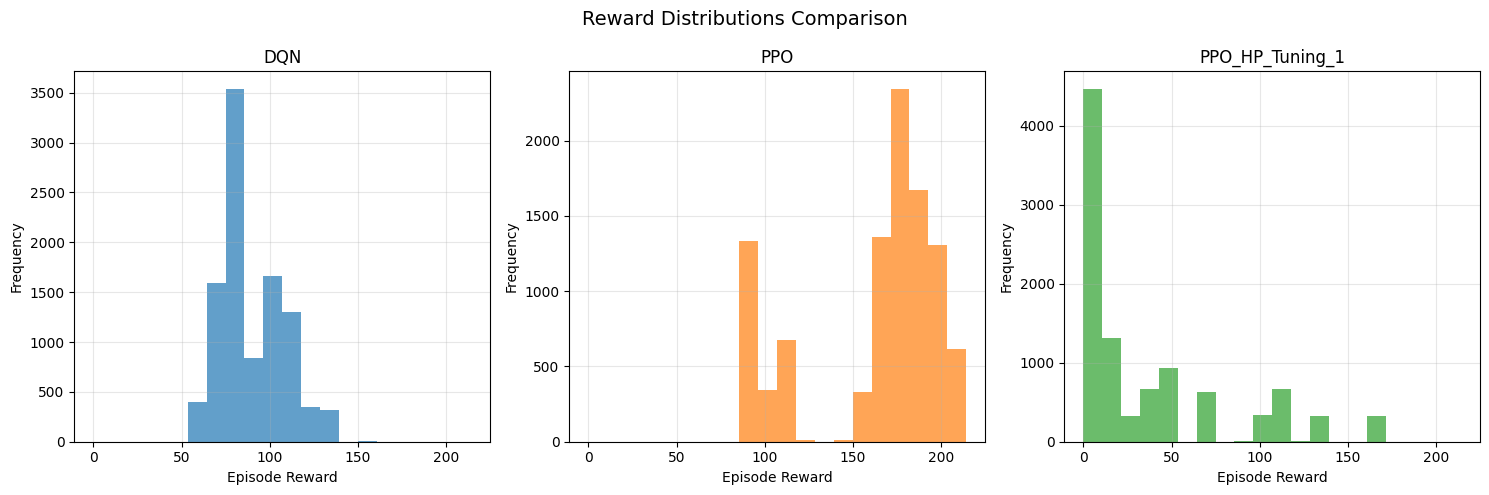

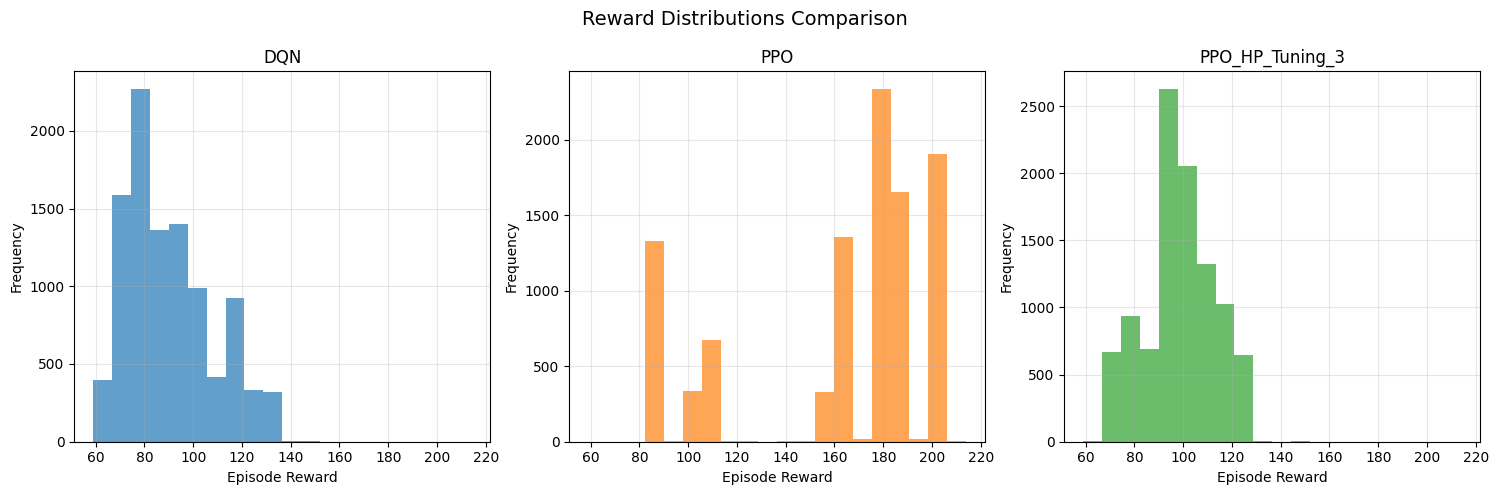

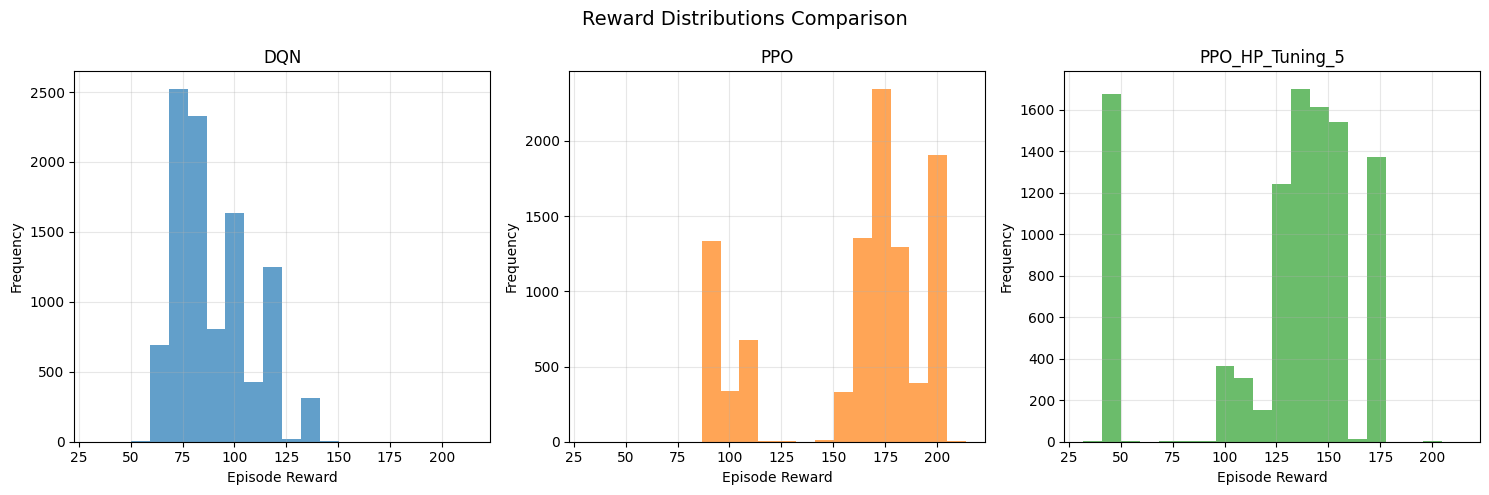

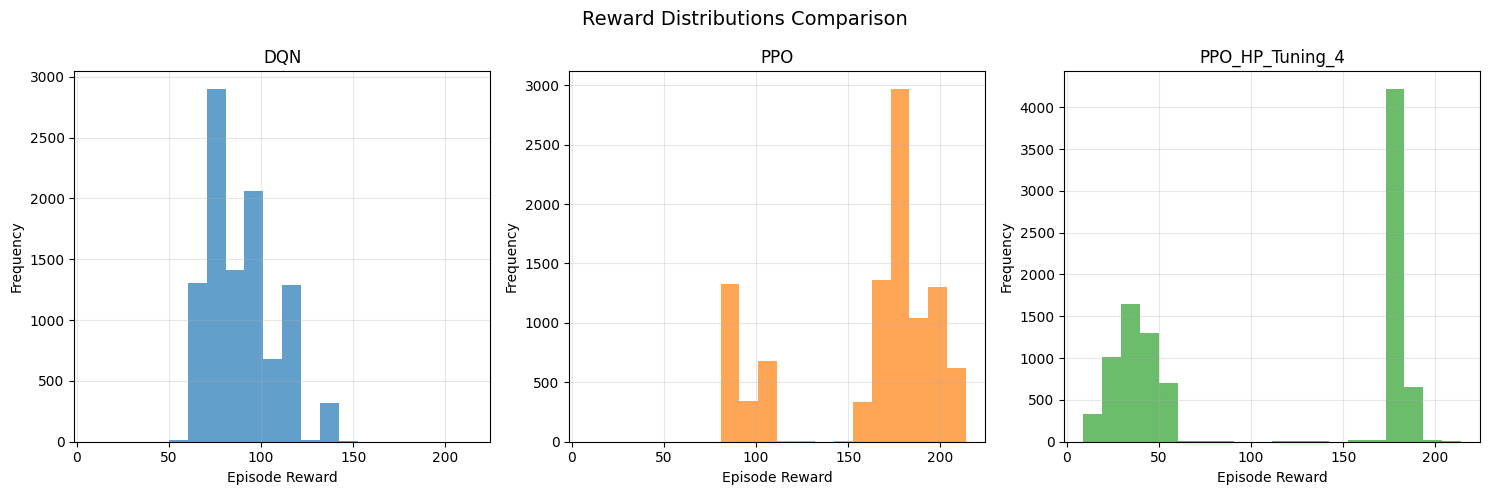

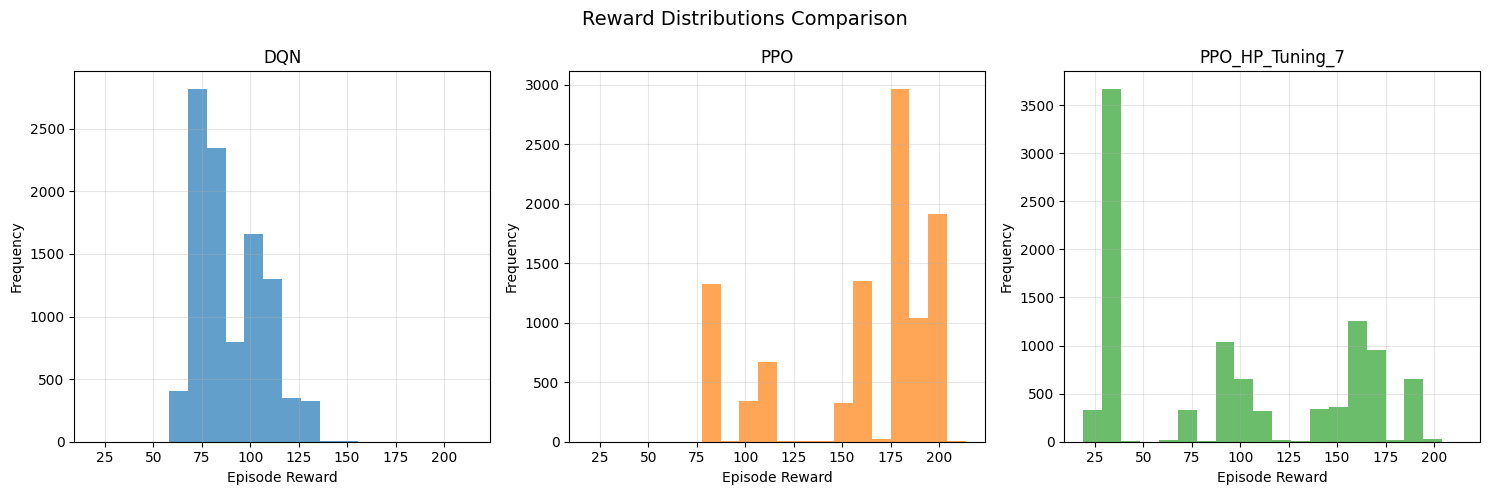

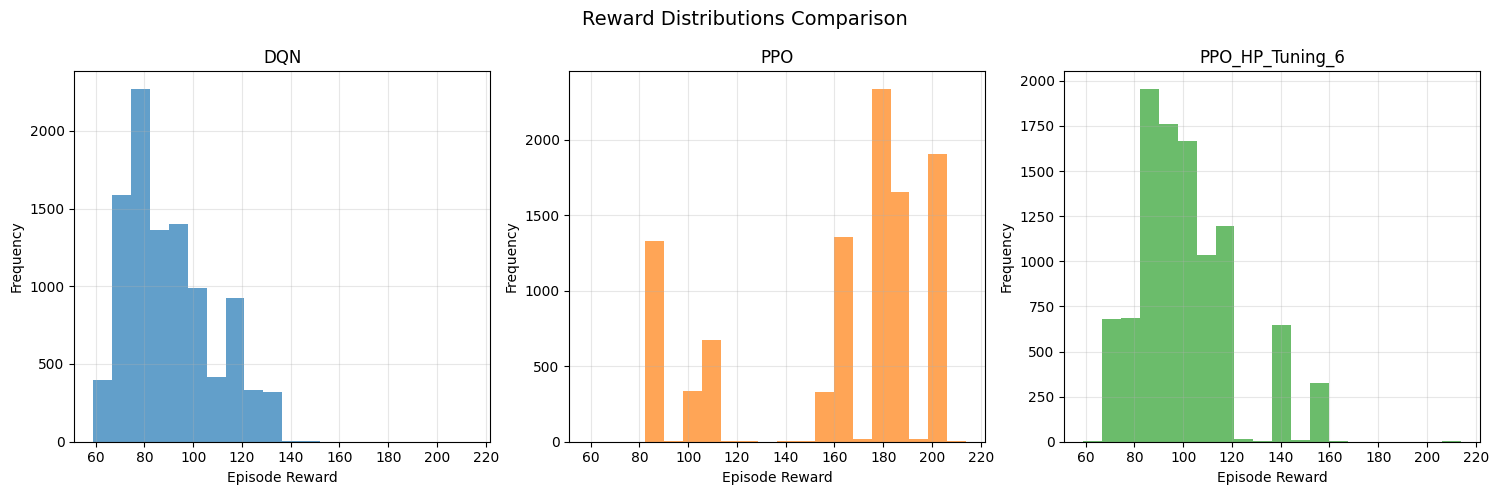

In [ ]:
# Side by side Histograms of DQN vs PPO vs PPO HP Tunings
keys = ["DQN", "PPO"]

for i in range(n):
  file_name = reward_file_names[i]
  label = labels[i]
  if "PPO" in label and label != "PPO":
    arr = load_npy_file(file_name)

    plot_three_histograms(results_dict[keys[0]], results_dict[keys[1]], arr, keys[0], keys[1], label)

/tmp/ipython-input-2941544914.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_arrays, labels=all_labels, showmeans=True)


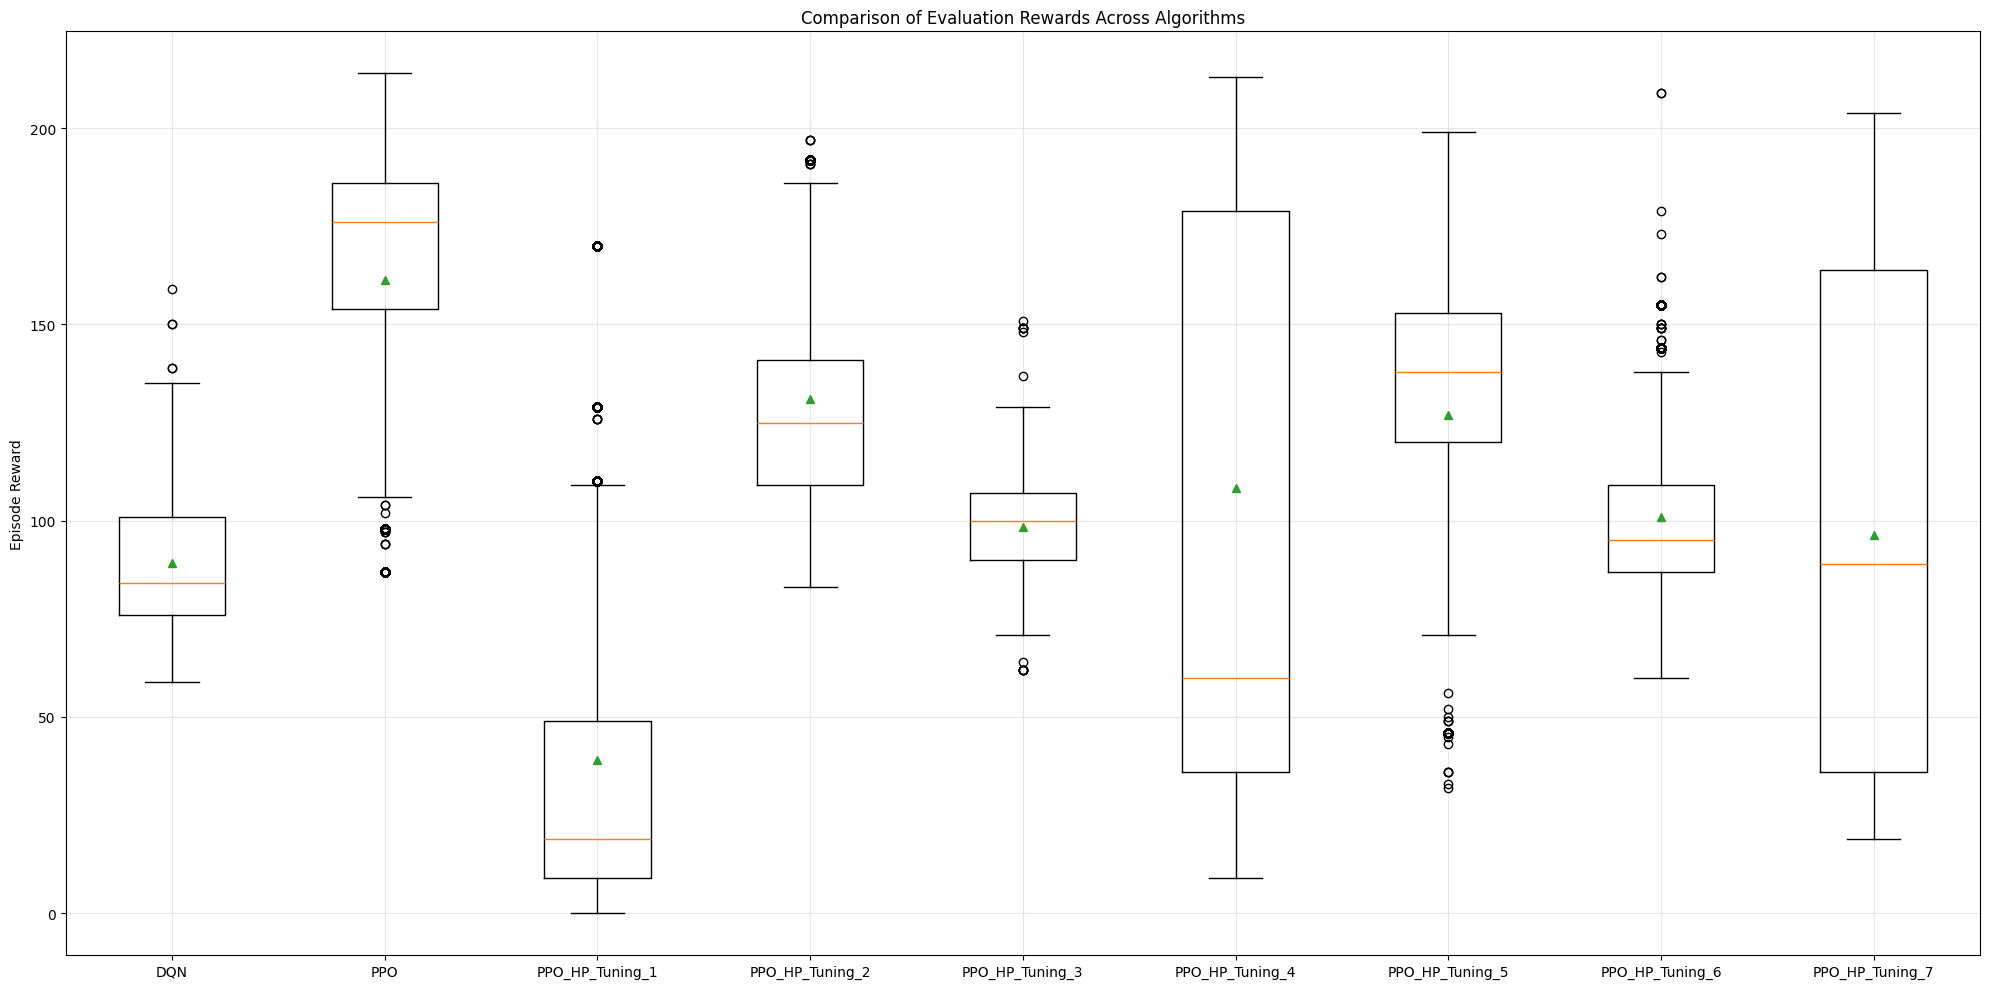

In [ ]:
# Box Plot of DQN vs PPO vs All PPO HP Tunings
box_plot_dict = {}

for i in range(n):
    file_name = reward_file_names[i]
    label = labels[i]
    if "DQN" == label or "PPO" in label:
      arr = load_npy_file(file_name)
      box_plot_dict[label] = arr

# Sort dictionary by keys, alphabetically
box_plot_dict_sorted = dict(sorted(box_plot_dict.items()))
all_arrays = list(box_plot_dict_sorted.values())
all_labels = list(box_plot_dict_sorted.keys())

# Box plot with all side by side
plt.figure(figsize=(20, 10))
plt.boxplot(all_arrays, labels=all_labels, showmeans=True)
plt.ylabel('Episode Reward')
plt.title('Comparison of Evaluation Rewards Across Algorithms')
plt.grid(True, alpha=0.3)
# plt.xticks(rotation=25)
plt.tight_layout()
plt.show()